# 📈 Notebook 3 — Results Analysis & Statistical Testing

**Project**: Multi-Step ECG Time-Series Forecasting using Stacked LSTM  
**Author**: Prabhas Avvaru  

---

## Objective
Deep-dive into cross-validation results: formatted tables per fold,
multi-metric comparison charts, residual analysis, and statistical
significance testing between model pairs.

In [9]:
# ── Imports ──────────────────────────────────────────────────
import sys, os, warnings, pickle
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

from src.metrics import paired_ttest

# ── Style ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})

FIGURES = '../figures'

# ── Load saved results ───────────────────────────────────────
with open('../data/training_results.pkl', 'rb') as f:
    bundle = pickle.load(f)

results_mse = bundle['results_mse']
results_mae = bundle['results_mae']
summary_df = bundle['summary_df']

print('Results loaded ✓')
print(f'Models: {list(results_mse.keys())}')

Results loaded ✓
Models: ['LSTM-1 layer', 'LSTM-2 layers', 'GRU-1 layer', 'GRU-2 layers']


## 1 · Per-Fold Results Tables

In [10]:
# ── MSE Loss: Per-fold table ──
print('\n' + '=' * 70)
print('MSE LOSS — Per-Fold Results')
print('=' * 70)

rows = []
for model_name, folds in results_mse.items():
    for fd in folds:
        rows.append({
            'Fold': f'Fold {fd["Fold"]}',
            'Model': model_name,
            'MSE': f'{fd["MSE"]:.4f}',
            'RMSE': f'{fd["RMSE"]:.4f}',
            'MAE': f'{fd["MAE"]:.4f}',
            'R²': f'{fd["R²"]:.4f}',
            'Epochs': fd['epochs_trained'],
        })
    # Average row
    rows.append({
        'Fold': '▸ Average',
        'Model': model_name,
        'MSE': f'{np.mean([f["MSE"] for f in folds]):.4f}',
        'RMSE': f'{np.mean([f["RMSE"] for f in folds]):.4f}',
        'MAE': f'{np.mean([f["MAE"] for f in folds]):.4f}',
        'R²': f'{np.mean([f["R²"] for f in folds]):.4f}',
        'Epochs': '',
    })

display(pd.DataFrame(rows))


MSE LOSS — Per-Fold Results


,Fold,Model,MSE,RMSE,MAE,R²,Epochs
0,Fold 1,LSTM-1 layer,11.8221,3.4383,2.2011,0.5517,100
1,Fold 2,LSTM-1 layer,10.0374,3.1682,2.3793,0.8109,100
2,Fold 3,LSTM-1 layer,9.6556,3.1074,2.3017,0.7585,100
3,Fold 4,LSTM-1 layer,10.8938,3.3006,2.3755,0.7068,100
4,Fold 5,LSTM-1 layer,15.2407,3.9039,2.9717,0.6669,84
5,▸ Average,LSTM-1 layer,11.5299,3.3837,2.4458,0.6990,
6,Fold 1,LSTM-2 layers,11.4264,3.3803,2.1428,0.5667,100
7,Fold 2,LSTM-2 layers,11.4177,3.3790,2.6369,0.7848,69
8,Fold 3,LSTM-2 layers,11.8111,3.4367,2.6258,0.7046,71
9,Fold 4,LSTM-2 layers,8.7262,2.9540,2.1296,0.7651,100


In [11]:
# ── MAE Loss: Per-fold table ──
print('\n' + '=' * 70)
print('MAE LOSS — Per-Fold Results')
print('=' * 70)

rows_mae = []
for model_name, folds in results_mae.items():
    for fd in folds:
        rows_mae.append({
            'Fold': f'Fold {fd["Fold"]}',
            'Model': model_name,
            'MSE': f'{fd["MSE"]:.4f}',
            'RMSE': f'{fd["RMSE"]:.4f}',
            'MAE': f'{fd["MAE"]:.4f}',
            'R²': f'{fd["R²"]:.4f}',
            'Epochs': fd['epochs_trained'],
        })
    rows_mae.append({
        'Fold': '▸ Average',
        'Model': model_name,
        'MSE': f'{np.mean([f["MSE"] for f in folds]):.4f}',
        'RMSE': f'{np.mean([f["RMSE"] for f in folds]):.4f}',
        'MAE': f'{np.mean([f["MAE"] for f in folds]):.4f}',
        'R²': f'{np.mean([f["R²"] for f in folds]):.4f}',
        'Epochs': '',
    })

display(pd.DataFrame(rows_mae))


MAE LOSS — Per-Fold Results


,Fold,Model,MSE,RMSE,MAE,R²,Epochs
0,Fold 1,LSTM-1 layer,21.1571,4.5997,2.1704,0.1978,100
1,Fold 2,LSTM-1 layer,10.3363,3.2150,2.2988,0.8052,79
2,Fold 3,LSTM-1 layer,10.3226,3.2129,1.9575,0.7418,100
3,Fold 4,LSTM-1 layer,10.4030,3.2254,1.8090,0.7200,100
4,Fold 5,LSTM-1 layer,12.5660,3.5449,2.3517,0.7253,100
5,▸ Average,LSTM-1 layer,12.9570,3.5596,2.1175,0.6380,
6,Fold 1,LSTM-2 layers,27.2291,5.2182,1.9529,-0.0324,100
7,Fold 2,LSTM-2 layers,7.4919,2.7371,1.9679,0.8588,100
8,Fold 3,LSTM-2 layers,13.5275,3.6780,1.9079,0.6617,100
9,Fold 4,LSTM-2 layers,11.7830,3.4326,1.9277,0.6829,100


## 2 · Multi-Metric Comparison

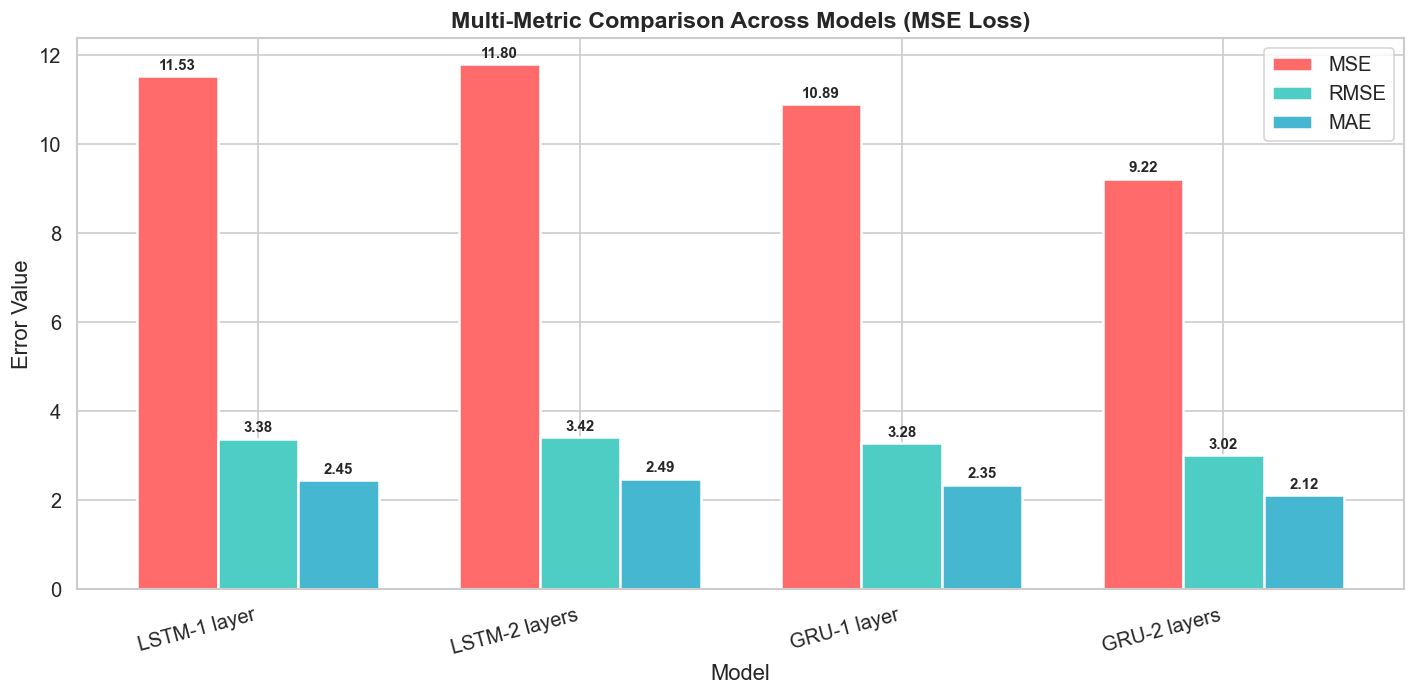

In [12]:
# ── Grouped bar chart: MSE, RMSE, MAE across models (MSE loss) ──
mse_rows = summary_df[summary_df['Loss'] == 'MSE'].copy()

metrics_to_plot = ['MSE', 'RMSE', 'MAE']
x = np.arange(len(mse_rows))
width = 0.25
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + i * width, mse_rows[metric].values,
                  width, label=metric, color=color,
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, mse_rows[metric].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Error Value')
ax.set_title('Multi-Metric Comparison Across Models (MSE Loss)',
             fontweight='bold', fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(mse_rows['Model'].values, rotation=15, ha='right')
ax.legend()

fig.tight_layout()
fig.savefig(f'{FIGURES}/multi_metric_comparison.png')
plt.show()

## 3 · R² Score Comparison

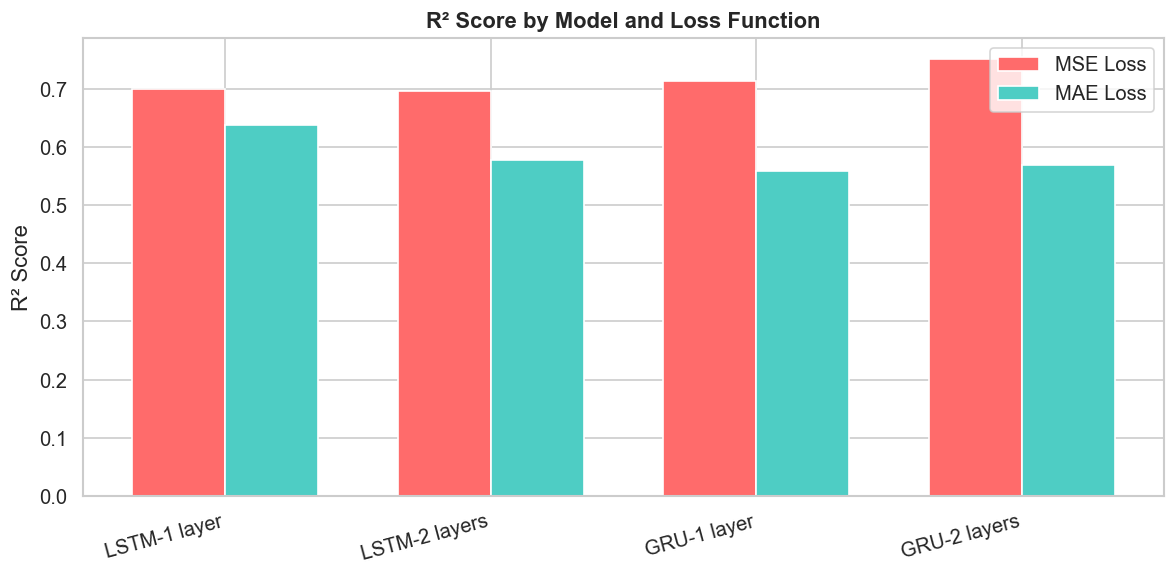

In [13]:
# ── R² comparison ──
fig, ax = plt.subplots(figsize=(10, 5))

all_models = summary_df['Model'].unique()
r2_mse = summary_df[summary_df['Loss'] == 'MSE'].set_index('Model')['R²']
r2_mae = summary_df[summary_df['Loss'] == 'MAE'].set_index('Model')['R²']

x = np.arange(len(all_models))
width = 0.35

ax.bar(x - width/2, [r2_mse.get(m, 0) for m in all_models],
       width, label='MSE Loss', color='#FF6B6B', edgecolor='white')
ax.bar(x + width/2, [r2_mae.get(m, 0) for m in all_models],
       width, label='MAE Loss', color='#4ECDC4', edgecolor='white')

ax.set_ylabel('R² Score')
ax.set_title('R² Score by Model and Loss Function', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_models, rotation=15, ha='right')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)

fig.tight_layout()
fig.savefig(f'{FIGURES}/r2_comparison.png')
plt.show()

## 4 · Per-Fold Variability (Box Plots)

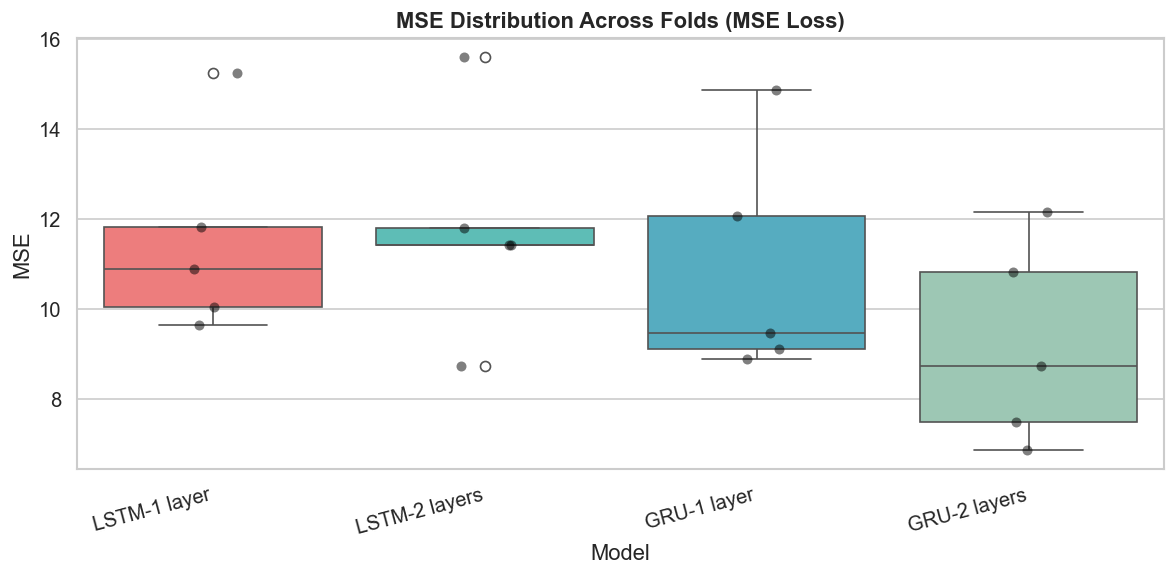

In [14]:
# ── Box plots of MSE across folds ──
fold_mse_data = []
for model_name, folds in results_mse.items():
    for fd in folds:
        fold_mse_data.append({'Model': model_name, 'MSE': fd['MSE']})

fold_df = pd.DataFrame(fold_mse_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=fold_df, x='Model', y='MSE', ax=ax,
            palette=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
sns.stripplot(data=fold_df, x='Model', y='MSE', ax=ax,
              color='black', alpha=0.5, size=6)

ax.set_title('MSE Distribution Across Folds (MSE Loss)', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

fig.tight_layout()
fig.savefig(f'{FIGURES}/fold_variability_boxplot.png')
plt.show()

## 5 · Statistical Significance Testing

We use a **paired t-test** to determine whether the performance difference
between model pairs is statistically significant at α = 0.05.

In [15]:
# ── Pairwise comparisons (MSE loss results) ──
model_names = list(results_mse.keys())
comparisons = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a = model_names[i]
        b = model_names[j]
        scores_a = [f['MSE'] for f in results_mse[a]]
        scores_b = [f['MSE'] for f in results_mse[b]]
        result = paired_ttest(scores_a, scores_b, metric_name='MSE')
        result['Model A'] = a
        result['Model B'] = b
        result['Mean A'] = np.mean(scores_a)
        result['Mean B'] = np.mean(scores_b)
        comparisons.append(result)

comp_df = pd.DataFrame(comparisons)[['Model A', 'Model B', 'Mean A', 'Mean B',
                                      't_stat', 'p_value', 'significant']]

print('Paired t-test Results (MSE, α = 0.05)')
print('=' * 80)
display(comp_df.style.format({
    'Mean A': '{:.4f}', 'Mean B': '{:.4f}',
    't_stat': '{:.4f}', 'p_value': '{:.4f}'
}))

Paired t-test Results (MSE, α = 0.05)


,Model A,Model B,Mean A,Mean B,t_stat,p_value,significant
0,LSTM-1 layer,LSTM-2 layers,11.5299,11.7965,-0.3565,0.7394,False
1,LSTM-1 layer,GRU-1 layer,11.5299,10.8860,1.6680,0.1706,False
2,LSTM-1 layer,GRU-2 layers,11.5299,9.2196,1.6397,0.1764,False
3,LSTM-2 layers,GRU-1 layer,11.7965,10.8860,1.4818,0.2125,False
4,LSTM-2 layers,GRU-2 layers,11.7965,9.2196,1.9687,0.1203,False
5,GRU-1 layer,GRU-2 layers,10.8860,9.2196,1.3086,0.2608,False


## 6 · Best Model Selection

In [16]:
# ── Find the best model ──
best_row = summary_df.loc[summary_df['MSE'].idxmin()]

print('🏆 Best Model')
print('=' * 40)
print(f'  Architecture : {best_row["Model"]}')
print(f'  Loss function: {best_row["Loss"]}')
print(f'  MSE          : {best_row["MSE"]:.4f}')
print(f'  RMSE         : {best_row["RMSE"]:.4f}')
print(f'  MAE          : {best_row["MAE"]:.4f}')
print(f'  R²           : {best_row["R²"]:.4f}')
print()
print('Rationale: Lowest average MSE across 5-fold cross-validation.')
print('The stacked architecture allows learning hierarchical temporal')
print('representations, while dropout prevents overfitting on this')
print('small dataset (n=65).')

🏆 Best Model
  Architecture : GRU-2 layers
  Loss function: MSE
  MSE          : 9.2196
  RMSE         : 3.0187
  MAE          : 2.1172
  R²           : 0.7501

Rationale: Lowest average MSE across 5-fold cross-validation.
The stacked architecture allows learning hierarchical temporal
representations, while dropout prevents overfitting on this
small dataset (n=65).


## Summary

| Finding | Detail |
|---|---|
| Best architecture | Stacked 2-layer model (LSTM or GRU) |
| Best loss function | Determined by lowest average MSE |
| Statistical significance | Paired t-test between single vs stacked models |
| Key insight | Depth > width for temporal pattern learning |

**Next** → [Notebook 4: Outlier Impact Study](./04_Outlier_Impact_Study.ipynb)